In [48]:
import cv2
import numpy as np


In [66]:


#using PIL image
from PIL import Image
import matplotlib.pyplot as plt
mask = Image.open("datasets/sam-unext_dataset/train/GT_object/17_79411_68002.png").convert('L')
# img = Image.open("datasets/sam-unext_dataset/images/17_79411_68002.tiff")


# pilimage to torch tensor
import torchvision.transforms as transforms
transform = transforms.ToTensor()
mask = transform(mask)



In [67]:
m = mask.numpy()
unique, counts = np.unique(m, return_counts=True)
print(dict(zip(unique, counts)))

{np.float32(0.0): np.int64(562), np.float32(1.0): np.int64(261582)}


In [47]:
img.shape

torch.Size([3, 512, 512])

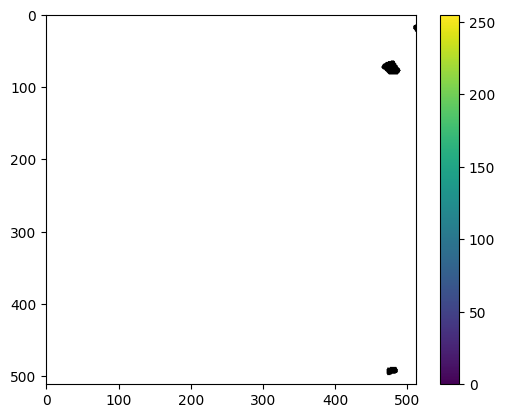

In [44]:
import matplotlib.pyplot as plt

# mask * -1 + 255

plt.imshow(mask)
# add color bar
plt.colorbar()
plt.show()

In [4]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import torch

In [12]:
sam2_tiny = build_sam2("sam2_hiera_t.yaml","src/sam2/checkpoints/sam2.1_hiera_tiny.pt")

In [49]:
import torchmetrics.segmentation as tms
dice_metric = tms.DiceScore(num_classes=2, include_background=False)
miou_metric = tms.MeanIoU(num_classes=2, include_background=False)

/home/auguste/Desktop/Cute_Track/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


In [54]:
x_1 = torch.randint(0,2,(8, 1, 200, 200))
x_2 = torch.randint(0,2,(8, 1, 200, 200))



# expect 0.1428 for dice and 0.0666 for miou




dice_score_1 = dice_metric(x_1, x_2)
miou_score_1 = miou_metric(x_1, x_2)
print(dice_score_1)
print(miou_score_1)


tensor(0.4993)
tensor(0.3327)


Train dataset size: 5
Val dataset size: 5
torch.Size([4, 3, 512, 512])
torch.Size([4, 1, 512, 512])


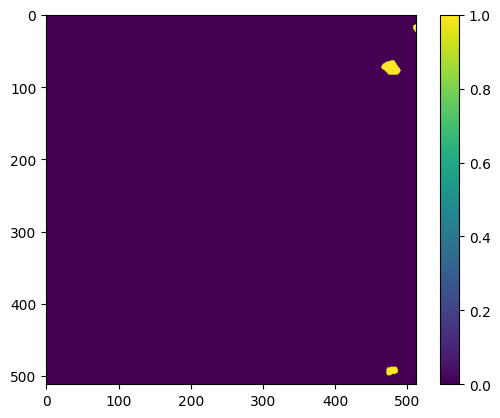

In [2]:
# test data module
data_module = DataModule512Mask(
    dataset_path="datasets/sam-unext_dataset",
    batch_size=4,
)
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()   

import matplotlib.pyplot as plt

img, mask = next(iter(train_loader))
print(img.shape)
print(mask.shape)

plt.imshow(mask[0,0,:,:])
plt.colorbar()
plt.show()

/home/auguste/Desktop/Cute_Track/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/auguste/Desktop/Cute_Track/.venv/lib/python3.13/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-lat

Train dataset size: 5
Val dataset size: 5
Train dataset size: 5
Val dataset size: 5
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/auguste/Desktop/Cute_Track/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


AttributeError: 'AttributeDict' object has no attribute 'dice_weight'